# Customer Segmentation Analysis using K-Means Clustering

## Objective
The objective of this project is to segment e-commerce customers based on their purchasing behaviour using the K-Means clustering algorithm.
Customer segmentation enables businesses to identify groups of customers with similar purchasing patterns, helping them develop personalized marketing strategies, improve customer retention, and increase sales.
This project uses the following Python libraries:
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
The analysis includes data preprocessing, RFM feature engineering (Recency, Frequency, Monetary), data standardization, K-Means clustering, cluster visualization, and business insights.

### Step 1: Import Libraries
## Why?
Before performing customer segmentation, we need several Python libraries for data manipulation, visualization, preprocessing, and machine learning.
- **Pandas** – Load and manipulate datasets.
- **NumPy** – Numerical and mathematical computations.
- **Matplotlib** – Create basic visualizations.
- **Seaborn** – Generate statistical plots.
- **Scikit-learn** – Perform data standardization and K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Matplotlib is building the font cache; this may take a moment.


### Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [3]:
df = pd.read_csv(
    "data.csv",
    encoding="utf-8",
    encoding_errors="replace"
)

### Step 3: Display First Five Records
Why? This helps us understand the structure of the dataset.

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [8]:
df.shape

(541909, 8)

#### Observation:
The dataset contains 541909 records and 8 columns. This indicates sufficient data for performing Customer Segmentation analysis.

### Step 6: Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Observation
- The dataset contains 541909 rows and 8 columns.
- There are no missing values in any column.
- The dataset contains both numerical and categorical variables.
- The Date column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 7: Check Missing Values and Duplicate Records

In [10]:
# Missing values
print("Missing Values:")
display(df.isnull().sum())

# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Missing Values:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268


#### Observation
- No missing values were found in **InvoiceNo, StockCode, Quantity, InvoiceDate, UnitPrice, and Country**.
- **Description** has **1,454** missing values.
- **CustomerID** has **135,080** missing values, so these rows will be removed for customer segmentation.
- The dataset contains **5,268** duplicate rows, which should be removed before analysis.

### Step 8: Handle Missing Values and Inconsistent Data

In [11]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Remove rows with missing Description
df.dropna(subset=['Description'], inplace=True)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove invalid Quantity and UnitPrice values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (392692, 8)


#### Observation
- Duplicate records and rows with missing **CustomerID** and **Description** were removed.
- **InvoiceDate** was converted to the correct datetime format.
- Transactions with invalid **Quantity** or **UnitPrice** values were filtered out.
- The cleaned dataset contains **392,692 rows** and **8 columns**, making it ready for customer segmentation analysis.

### Step 9: Verify the Cleaned Dataset

In [12]:
print("Missing Values After Cleaning:")
display(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:", df.duplicated().sum())

print("\nFinal Dataset Shape:", df.shape)

df.head()

Missing Values After Cleaning:


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


Duplicate Rows After Cleaning: 0

Final Dataset Shape: (392692, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Observation
- All missing values and duplicate records have been successfully removed.
- The cleaned dataset contains **392,692 rows** and **8 columns**.
- The dataset is now clean, consistent, and ready for feature engineering and K-Means clustering.

### Step 10: Descriptive statistics

In [13]:
# Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Average Purchase Value
average_purchase_value = df['TotalAmount'].mean()

# Purchase Frequency (transactions per customer)
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Customer Lifetime Value (total spending per customer)
customer_lifetime_value = df.groupby('CustomerID')['TotalAmount'].sum()

print(f"Average Purchase Value: £{average_purchase_value:.2f}")

print("\nPurchase Frequency (First 5 Customers):")
display(purchase_frequency.head())

print("\nCustomer Lifetime Value (First 5 Customers):")
display(customer_lifetime_value.head())

Average Purchase Value: £22.63

Purchase Frequency (First 5 Customers):


CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64


Customer Lifetime Value (First 5 Customers):


CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: TotalAmount, dtype: float64

####  Observation
- The average purchase value indicates the typical amount spent per transaction.
- Purchase frequency varies across customers, showing differences in buying behaviour.
- Customer Lifetime Value (CLV) helps identify high-value customers based on their total spending.

### Step 11: Feature selection

In [14]:
# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Reference date (1 day after the last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first few rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


#### Observation
- Three behavioural features (**Recency, Frequency, and Monetary**) were successfully created for each customer.
- These RFM features summarize customer purchasing behaviour and will be used as the input for K-Means clustering.

### Step 12: Data normalisation

In [15]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Standardize the RFM features
rfm_scaled = scaler.fit_transform(rfm)

# Convert to DataFrame for better visualization
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

# Display the first 5 rows
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


#### Observation
- The RFM features were successfully standardized using **StandardScaler**.
- After standardization, all features have a similar scale, making them suitable for K-Means clustering.
- This prevents features with larger values from dominating the clustering process.

### Step 13: K-Means clustering 

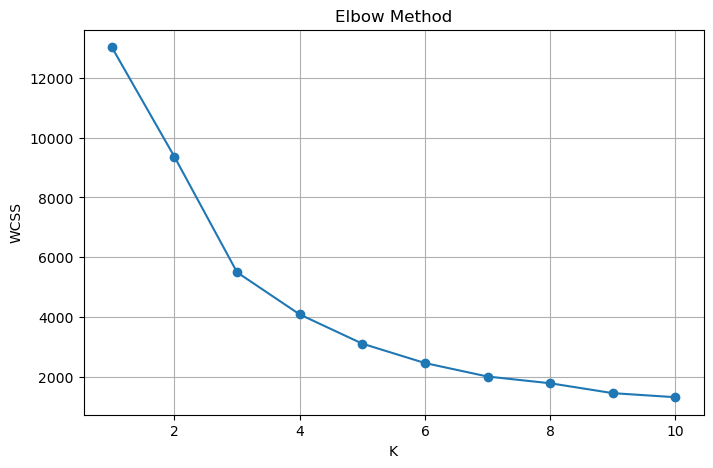

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cluster_results = {}

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    cluster_results[k] = model.inertia_

plt.figure(figsize=(8,5))
plt.plot(list(cluster_results.keys()),
         list(cluster_results.values()),
         marker='o')

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

#### Observation
- The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.
- The WCSS decreases as the number of clusters increases, indicating improved cluster compactness.
- The elbow point suggests the optimal value of **K**, which is used for customer segmentation.

### Step 14: Cluster Visualization

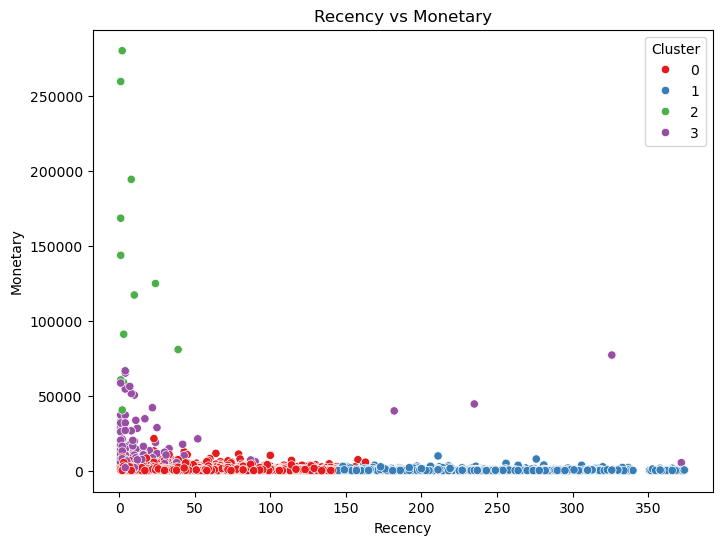

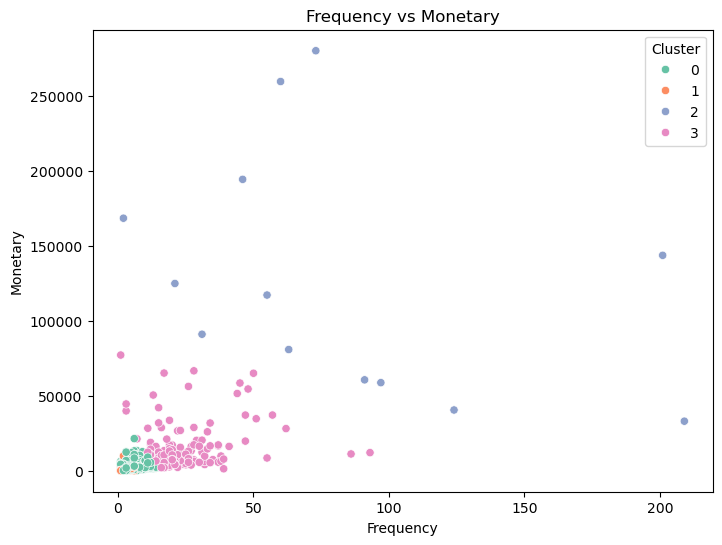

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

#Scatter Plot 1 (Recency vs Monetary)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.show()

#Scatter Plot 2 (Frequency vs Monetary)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.show()

#### Observation
- The scatter plots show distinct customer clusters based on RFM features.
- Customers within the same cluster have similar purchasing behaviour, while different clusters exhibit different spending and purchasing patterns.
- These visualizations help identify high-value, frequent, and inactive customer segments.

### Step 15: Profile each cluster

In [25]:
# Calculate cluster profile
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# Create customer type based on RFM values
customer_type = []

for _, row in cluster_profile.iterrows():
    if row['Frequency'] >= cluster_profile['Frequency'].mean() and row['Monetary'] >= cluster_profile['Monetary'].mean():
        customer_type.append("Loyal Customers")
    elif row['Recency'] <= cluster_profile['Recency'].mean() and row['Frequency'] >= cluster_profile['Frequency'].mean():
        customer_type.append("Potential Loyal Customers")
    elif row['Recency'] > cluster_profile['Recency'].mean():
        customer_type.append("At-Risk Customers")
    else:
        customer_type.append("Occasional Customers")

# Add customer type to cluster profile
cluster_profile['Customer Type'] = customer_type

# Display the cluster profile
cluster_profile

,Recency,Frequency,Monetary,Customer Type
Cluster,,,,
0,43.70,3.68,1353.63,Occasional Customers
1,248.08,1.55,478.85,At-Risk Customers
2,7.38,82.54,127187.96,Loyal Customers
3,15.50,22.33,12690.50,Occasional Customers


#### Observation
- The average RFM values were calculated for each cluster to understand customer purchasing behaviour.
- Each cluster represents a distinct customer segment, such as loyal, potential loyal, occasional, or at-risk customers.
- These customer profiles help businesses develop targeted marketing and customer retention strategies.

### Step 16: Number of Customers per Cluster

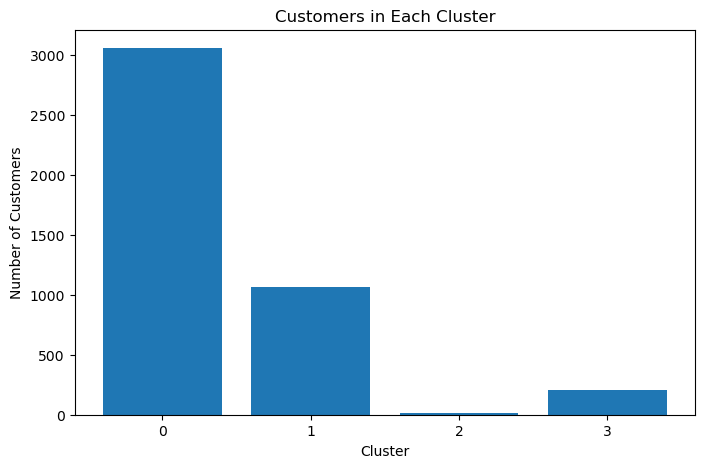

In [30]:
import matplotlib.pyplot as plt

# Customer count per cluster
counts = rfm.groupby('Cluster').size()

plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(counts.index)

plt.show()

#### Observation
- The bar chart displays the number of customers in each cluster.
- The distribution shows that some clusters contain more customers than others.
- This helps identify the relative size of each customer segment for business analysis.

### Step 17:  Insights 

#### Marketing Actions for Each Customer Segment
| Customer Segment | Characteristics | Recommended Marketing Action |
|------------------|-----------------|-------------------------------|
| **Loyal Customers** | High purchase frequency and high spending | Reward with loyalty programs, exclusive discounts, and early access to new products. |
| **Potential Loyal Customers** | Recent purchases with moderate spending | Encourage repeat purchases through personalized recommendations and special offers. |
| **Occasional Customers** | Low purchase frequency and moderate spending | Send promotional emails, seasonal discounts, and product suggestions to increase engagement. |
| **At-Risk Customers** | Long time since last purchase and low activity | Re-engage with win-back campaigns, limited-time discounts, and reminder emails. |


### Step 18: Conclusion

In [ ]:
### Conclusion
- Customer segmentation using K-Means clustering successfully grouped customers based on their purchasing behaviour. 
- By identifying different customer segments, businesses can implement targeted marketing strategies, improve customer retention, and maximize overall revenue.